# From hidden states to reasoning trajectories

**Representation lab | 35-45 minutes | offline and laptop-friendly**

Prediction asks what decision will occur. Representation asks a different question:

> What information is present in a system state while the decision is being formed?

## The controlled setup

GPT-4 generated 1,368 choice-and-reasoning records from 72 synthetic participants, five prompted decision personas, and 19 risky-choice questions. We use this as a controlled stand-in for the kind of choice + process dataset one might receive from human participants.

Before analysis, the final A/B statement is replaced by **Option X** and the persona prompt is hidden. A separate frozen open-weight model, Qwen3.5-9B, receives only the question and masked reasoning. This lets us inspect internal activations without asking the closed generator to interpret itself.

All expensive model runs are cached, so this notebook performs only lightweight analysis.

## The question chain

1. Is the hidden choice recoverable from the masked reasoning?
2. How does that information emerge sentence by sentence?
3. Do the five personas follow different trajectories on the same problem?
4. Which decision variables might organize those differences?
5. Does the interpretable representation predict held-out choices?
6. Which claims remain descriptive, predictive, or causal?

## 1. Why study representation after prediction?

The same observed choice can be supported by different internal information: expected value, safety, a salient payoff, or a simple heuristic. Prediction alone cannot distinguish these routes.

For a reasoning prefix \(x_{\leq t}\), a language model produces a contextual state:

\[
h_t = f_\theta(x_{\leq t}).
\]

This vector is a **representation** because downstream computations can use it. It is not automatically interpretable. We therefore learn or specify a readout:

\[
z_t = g(h_t), \qquad \hat{y}=q(z_t).
\]

- \(h_t\): thousands of residual-stream coordinates from one model layer;
- \(g\): a linear probe, small neural network, sparse autoencoder, or another readout;
- \(z_t\): candidate interpretable decision coordinates;
- \(q\): a downstream model predicting choice or another behavioral variable.

**Resulting question:** before interpreting a state, can we establish that the masked reasoning contains recoverable choice information?

## 2. What exactly was measured before class?

### Step 1: reformat one observed record

Qwen receives a choice-recovery instruction, the risky-choice question, and the GPT-4 reasoning prefix whose final A/B statement was replaced by **Option X**. It does not receive the persona prompt, the original conclusion, or GPT-4 activations.

### Step 2: extract Qwen states

For each sentence-ending token \(t_s\), we save

\[
h_{l,t_s}=f_l(x_{\leq t_s})
\]

from layer 00 and all 32 transformer-block outputs. Each vector contains 4,096 numbers. These are **Qwen contextual hidden states for GPT-4-generated text**. They are not GPT-4 embeddings and they are not isolated sentence vectors.

### Step 3: fit two different readouts

| Readout | Training records | Input | Target | Scientific role |
|---|---|---|---|---|
| Choice probe | masked GPT-4 reasoning traces | final-prefix Qwen state from each layer | original A/B choice | locate layers with recoverable choice information |
| Text2Decision | Choice13K single-option descriptions | Qwen layer-15 state of each option text | 12 computed lottery variables | give the reasoning trajectory candidate interpretable coordinates |

The choice probe is standardization plus logistic regression and holds out entire questions. Text2Decision is an MLP with dimensions `4096 -> 512 -> 128 -> 64 -> 12`, trained with Choice13K problem IDs held out. After training, Text2Decision is frozen and transferred to the sentence-prefix states of the GPT-4 reasoning traces.

**Resulting question:** does the first readout show that the masked reasoning actually contains recoverable choice information?

In [1]:
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 120)

sns.set_theme(style="whitegrid", context="talk")
PALETTE = {
    "Outcome-Focused Decision-Maker": "#4C78A8",
    "Probability-Weighted Decision-Maker": "#F58518",
    "Rational Decision-Maker": "#54A24B",
    "Risk-Averse": "#E45756",
    "Risk-Seeking": "#B279A2",
}

def find_repo_root():
    candidates = [Path.cwd(), Path.cwd().parent, Path("/content/LLM_human_decisions")]
    for candidate in candidates:
        if (candidate / "notebooks" / "results" / "representation").exists():
            return candidate
    raise FileNotFoundError(
        "Run this notebook from the repository root or the notebooks directory."
    )

ROOT = find_repo_root()
RESULTS = (
    ROOT / "notebooks" / "results" / "representation"
    / "text2decision_multiscale_log_trajectories"
)
PERSONA_RESULTS = RESULTS / "persona_dimension_trends"

states = pd.read_csv(RESULTS / "sentence_decision_states.csv")
timecourse = pd.read_csv(PERSONA_RESULTS / "persona_dimension_timecourse.csv")
endpoint = pd.read_csv(PERSONA_RESULTS / "persona_dimension_endpoint.csv")
choice_progress = pd.read_csv(RESULTS / "choice_prediction_by_progress.csv")

print(f"Repository: {ROOT}")
print(f"Sentence-prefix states: {len(states):,}")
print(f"Trials: {states['trial_row'].nunique():,}")
print(f"Questions: {states['question_id'].nunique()}")
print(f"Personas: {states['persona'].nunique()}")

Repository: C:\Users\Hanbo\Documents\GitHub\LLM_human_decisions
Sentence-prefix states: 11,642
Trials: 1,368
Questions: 19
Personas: 5


## 3. A trajectory is a sequence of cumulative prefixes

The unit of analysis is not an isolated sentence. At step \(t\), the model sees:

```text
question + sentence 1 + ... + sentence t
```

This matters because the state at sentence 3 can retain information introduced
in sentences 1 and 2. Inspect one masked trace below.

In [2]:
example_trial = (
    states.loc[~states["is_masked_conclusion"]]
    .groupby("trial_row")
    .size()
    .sort_values(ascending=False)
    .index[0]
)

example = (
    states.loc[
        (states["trial_row"] == example_trial)
        & (~states["is_masked_conclusion"]),
        ["sentence_index", "sentence_text", "model_p_b", "persona", "question_id"],
    ]
    .sort_values("sentence_index")
    .reset_index(drop=True)
)

print("Persona:", example.loc[0, "persona"])
print("Question:", example.loc[0, "question_id"])
display(example[["sentence_index", "sentence_text", "model_p_b"]])

Persona: Risk-Seeking
Question: Q01


,sentence_index,sentence_text,model_p_b
0,0,"Looking at these two options, I'm seeing a pretty stark contrast.",0.437824
1,1,Option B is a sure thing.,0.437824
2,2,"I get $240, no ifs, ands, or buts about it.",0.437824
3,3,It's guaranteed money in my pocket.,0.437824
4,4,"That's pretty appealing, but there's something about Option A that's really drawing me in.",0.437824
5,5,"With Option A, there's a chance I could walk away with nothing.",0.437824
6,6,"A 75% chance, to be exact.",0.437824
7,7,That's pretty high.,0.437824
8,8,But there's also that 25% chance I could get $1000.,0.437824
9,9,That's a lot more money.,0.437824


### A crucial control: the question is already in the context

Lottery values strongly organize the raw hidden-state space. To study reasoning
style rather than question identity, we:

1. subtract the shared question-only onset;
2. resample each trace at 0%, 25%, 50%, 75%, and 100% of reasoning;
3. within each exact question, progress point, and dimension, subtract the
   average across personas;
4. average the remaining persona-relative changes.

The resulting curves answer:

> For the same question and reasoning stage, how does this persona differ from the others?

They do **not** directly estimate psychological sensitivity or causal influence.

**Result:** after controlling question identity, persona paths can be compared. **Next question:** distance shows that paths differ, but what do those differences mean?


## 4. Which decision variables differentiate the five reasoning paths?

First inspect the endpoint as a compact heatmap. Positive values mean that a
persona ends above the same-question, same-progress persona average; negative
values mean it ends below that reference.

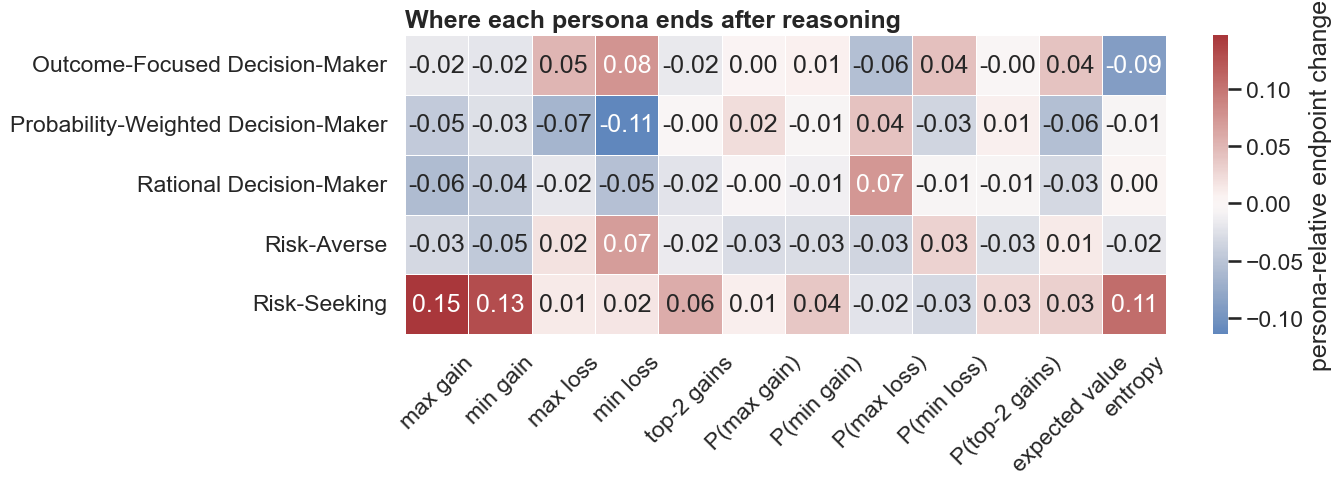

In [3]:
DIMENSION_LABELS = {
    "maximum_gain": "max gain",
    "minimum_gain": "min gain",
    "maximum_loss": "max loss",
    "minimum_loss": "min loss",
    "sum_two_largest_gains": "top-2 gains",
    "probability_maximum_gain": "P(max gain)",
    "probability_minimum_gain": "P(min gain)",
    "probability_maximum_loss": "P(max loss)",
    "probability_minimum_loss": "P(min loss)",
    "probability_two_largest_gains": "P(top-2 gains)",
    "expected_value": "expected value",
    "entropy": "entropy",
}

persona_order = list(PALETTE)
dimension_order = list(DIMENSION_LABELS)

heat = (
    endpoint.pivot(index="persona", columns="dimension", values="mean_centered_delta")
    .reindex(index=persona_order, columns=dimension_order)
    .rename(columns=DIMENSION_LABELS)
)

fig, ax = plt.subplots(figsize=(14, 5.2))
sns.heatmap(
    heat,
    cmap="vlag",
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"label": "persona-relative endpoint change"},
    ax=ax,
)
ax.set(xlabel="", ylabel="")
ax.tick_params(axis="x", rotation=45)
ax.tick_params(axis="y", rotation=0)
ax.set_title("Where each persona ends after reasoning", loc="left", weight="bold")
plt.tight_layout()
plt.show()

In [4]:
ranked = (
    endpoint.assign(abs_change=lambda d: d["mean_centered_delta"].abs())
    .sort_values(["persona", "abs_change"], ascending=[True, False])
    .groupby("persona", as_index=False)
    .head(4)
    .assign(
        dimension=lambda d: d["dimension"].map(DIMENSION_LABELS),
        direction=lambda d: np.where(
            d["mean_centered_delta"] >= 0, "higher than peers", "lower than peers"
        ),
    )
)
display(
    ranked[
        ["persona", "dimension", "mean_centered_delta", "sem_centered_delta", "direction"]
    ].reset_index(drop=True)
)

,persona,dimension,mean_centered_delta,sem_centered_delta,direction
0,Outcome-Focused Decision-Maker,entropy,-0.089292,0.013668,lower than peers
1,Outcome-Focused Decision-Maker,min loss,0.076228,0.012711,higher than peers
2,Outcome-Focused Decision-Maker,P(max loss),-0.055741,0.014752,lower than peers
3,Outcome-Focused Decision-Maker,max loss,0.049944,0.012494,higher than peers
4,Probability-Weighted Decision-Maker,min loss,-0.114201,0.017115,lower than peers
5,Probability-Weighted Decision-Maker,max loss,-0.065414,0.016291,lower than peers
6,Probability-Weighted Decision-Maker,expected value,-0.055364,0.015716,lower than peers
7,Probability-Weighted Decision-Maker,max gain,-0.045862,0.014277,lower than peers
8,Rational Decision-Maker,P(max loss),0.073942,0.011743,higher than peers
9,Rational Decision-Maker,max gain,-0.058851,0.012537,lower than peers


### Do not infer a trajectory from its endpoint alone

An endpoint can hide reversals. The next plot shows four theoretically useful
coordinates across normalized reasoning progress.

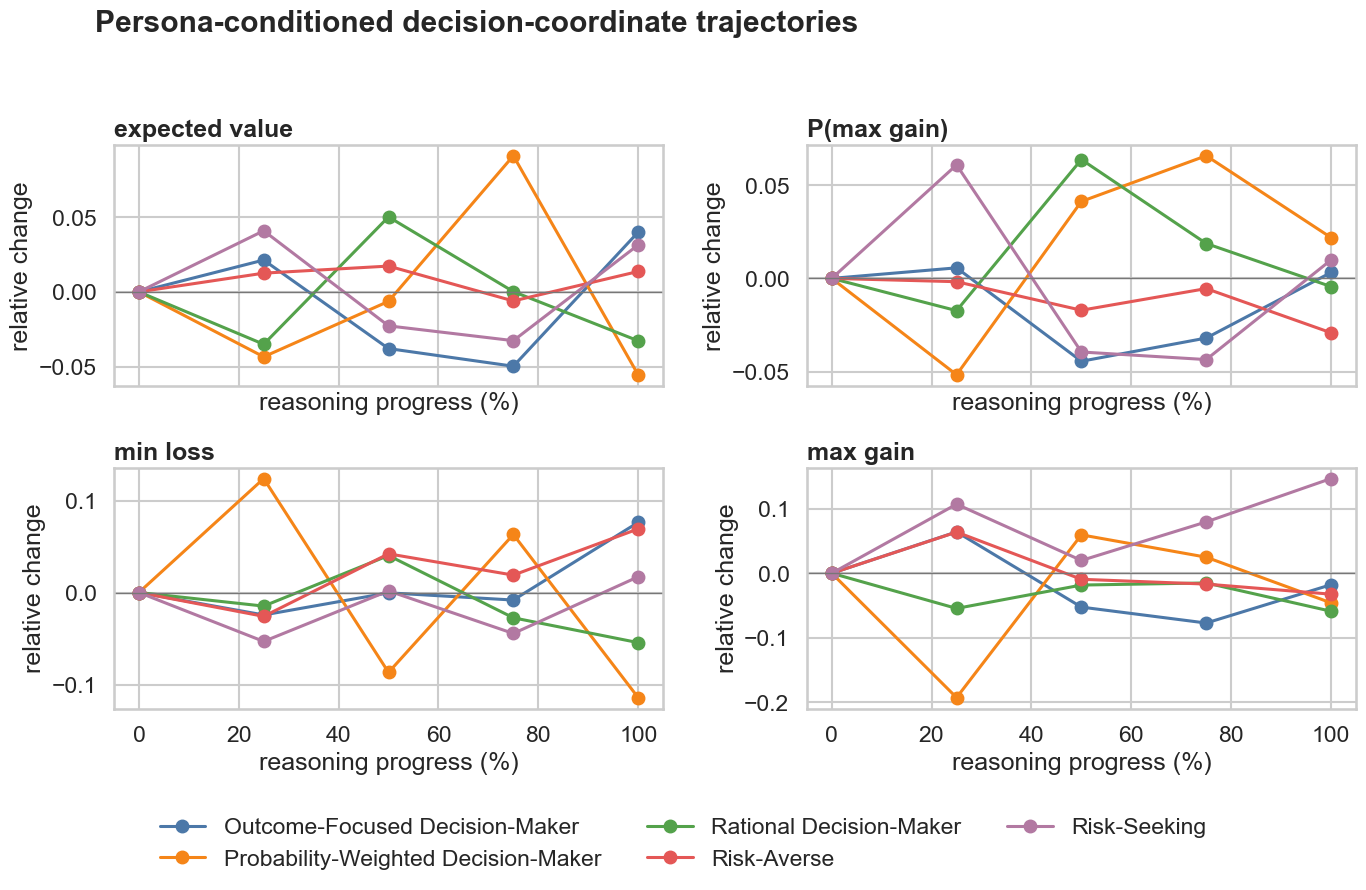

In [5]:
selected_dimensions = [
    "expected_value",
    "probability_maximum_gain",
    "minimum_loss",
    "maximum_gain",
]

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
for ax, dimension in zip(axes.flat, selected_dimensions):
    panel = timecourse.loc[timecourse["dimension"] == dimension]
    for persona in persona_order:
        rows = panel.loc[panel["persona"] == persona].sort_values("progress")
        ax.plot(
            rows["progress"] * 100,
            rows["mean_centered_delta"],
            marker="o",
            linewidth=2.2,
            color=PALETTE[persona],
            label=persona,
        )
    ax.axhline(0, color="#777777", linewidth=1)
    ax.set_title(DIMENSION_LABELS[dimension], loc="left", weight="bold")
    ax.set_xlabel("reasoning progress (%)")
    ax.set_ylabel("relative change")

handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3, frameon=False)
fig.suptitle(
    "Persona-conditioned decision-coordinate trajectories",
    x=0.08,
    ha="left",
    weight="bold",
)
plt.tight_layout(rect=[0, 0.10, 1, 0.95])
plt.show()

### Initial interpretation

Some patterns match the persona prompts:

- **Risk-Seeking** ends strongly toward maximum gain and minimum gain.
- **Risk-Averse** shows a relative emphasis on minimum loss and its probability.
- **Outcome-Focused** shows prominent outcome-magnitude changes and lower entropy.

Other patterns challenge the labels:

- **Rational** does not show a stable, monotonic expected-value trajectory.
- **Probability-Weighted** is not dominated by probability coordinates.

This mismatch is informative. A persona label does not guarantee that the
generated language or internal representation implements the named strategy.

## 5. Do the inferred coordinates agree with the words?

Interpretability should not rest on the readout alone. We now perform a simple
lexical audit on the pre-conclusion reasoning. This is intentionally a weak
baseline: it can reveal explicit verbal emphasis, but it cannot detect implicit
computation.

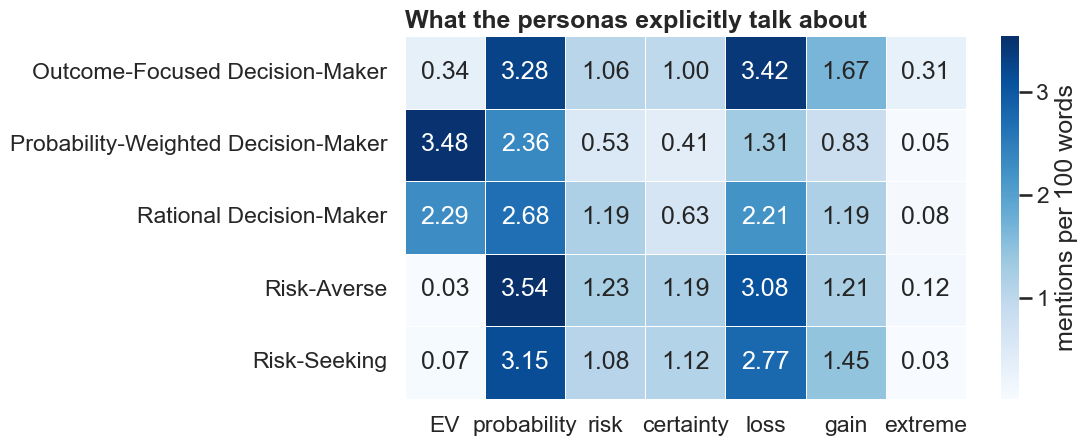

In [6]:
LEXICAL_PATTERNS = {
    "EV": r"\bexpected value\b|\baverage (?:value|return|payoff)\b",
    "probability": r"\bprobabilit(?:y|ies)\b|\bchance\b|\blikely\b|\blikelihood\b",
    "risk": r"\brisk(?:y|ier|iest)?\b|\bvariance\b|\buncertain(?:ty)?\b",
    "certainty": r"\bcertain(?:ty)?\b|\bguarantee(?:d)?\b|\bsure\b|\bsafe(?:r|st)?\b",
    "loss": r"\bloss(?:es)?\b|\blose\b|\blosing\b|\bdownside\b",
    "gain": r"\bgain(?:s)?\b|\bwin(?:ning)?\b|\bupside\b|\bprofit\b",
    "extreme": r"\bmaximum\b|\bminimum\b|\bbest case\b|\bworst case\b|\bextreme\b",
}

reasoning = (
    states.loc[~states["is_masked_conclusion"]]
    .sort_values(["trial_row", "sentence_index"])
    .groupby(["trial_row", "persona"], as_index=False)
    .agg(text=("sentence_text", " ".join))
)
reasoning["n_words"] = reasoning["text"].str.split().str.len().clip(lower=1)

for label, pattern in LEXICAL_PATTERNS.items():
    counts = reasoning["text"].str.count(pattern, flags=re.IGNORECASE)
    reasoning[label] = 100 * counts / reasoning["n_words"]

lexical = (
    reasoning.groupby("persona")[list(LEXICAL_PATTERNS)]
    .mean()
    .reindex(persona_order)
)

fig, ax = plt.subplots(figsize=(11.5, 4.8))
sns.heatmap(
    lexical,
    cmap="Blues",
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"label": "mentions per 100 words"},
    ax=ax,
)
ax.set(xlabel="", ylabel="")
ax.tick_params(axis="x", rotation=0)
ax.tick_params(axis="y", rotation=0)
ax.set_title("What the personas explicitly talk about", loc="left", weight="bold")
plt.tight_layout()
plt.show()

### Representation-language convergence and disagreement

The lexical audit partially supports the trajectory interpretation:

- Risk-Averse language emphasizes probability, certainty, and loss.
- Outcome-Focused language emphasizes losses, gains, and extreme outcomes.
- Rational language mentions expected value more than most personas.

But Probability-Weighted language mentions expected value even more often than
Rational language. This suggests that the generator operationalized the persona
prompt in an unexpected way.

The correct response is not to choose whichever analysis fits the label. The
disagreement becomes a new, testable question.

## 6. Does the representation predict behavior?

A representation may look interpretable without carrying behaviorally useful
information. We therefore evaluate a choice decoder on held-out questions.

Two representations are compared:

- the complete 12-dimensional decision state;
- a single scalar measuring position along an Option-A-to-Option-B axis.

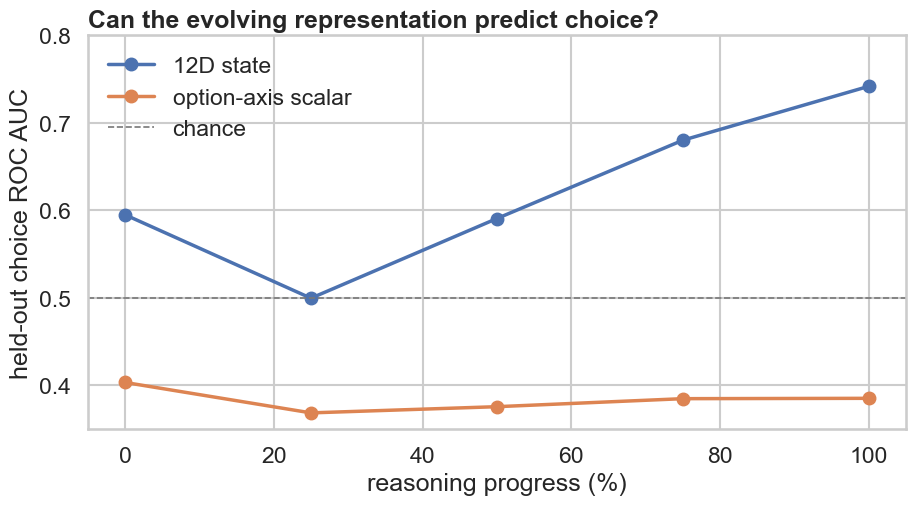

,progress,representation,balanced_accuracy,roc_auc,log_loss
0,0.00,12D state,0.561210,0.594951,0.698571
1,0.25,12D state,0.474979,0.499581,0.698553
2,0.50,12D state,0.550929,0.590624,0.670713
3,0.75,12D state,0.631007,0.680134,0.628696
4,1.00,12D state,0.656068,0.741754,0.597763
5,0.00,option-axis scalar,0.500000,0.403303,0.695422
6,0.25,option-axis scalar,0.483447,0.368514,0.699199
7,0.50,option-axis scalar,0.500265,0.375600,0.693878
8,0.75,option-axis scalar,0.493662,0.384761,0.693990
9,1.00,option-axis scalar,0.486477,0.385151,0.695694


In [7]:
fig, ax = plt.subplots(figsize=(9.5, 5.4))
for representation, rows in choice_progress.groupby("representation"):
    rows = rows.sort_values("progress")
    ax.plot(
        rows["progress"] * 100,
        rows["roc_auc"],
        marker="o",
        linewidth=2.5,
        label=representation,
    )

ax.axhline(0.5, color="#777777", linestyle="--", linewidth=1.2, label="chance")
ax.set(
    xlabel="reasoning progress (%)",
    ylabel="held-out choice ROC AUC",
    ylim=(0.35, 0.80),
)
ax.set_title("Can the evolving representation predict choice?", loc="left", weight="bold")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

display(
    choice_progress.sort_values(["representation", "progress"])[
        ["progress", "representation", "balanced_accuracy", "roc_auc", "log_loss"]
    ].reset_index(drop=True)
)

### What this establishes - and what it does not

The full 12-dimensional state reaches useful held-out choice decoding, whereas
the simple option-axis scalar remains weak. Therefore:

- the reasoning representation contains choice-relevant information;
- that information is distributed across several coordinates;
- distance to isolated option-text anchors is not a sufficient explanation.

This does **not** show that the 12 coordinates are the true computations used by
the generator or by humans.

## 7. The evidence ladder

| Claim | Evidence in this notebook | Status |
|---|---|---|
| Reasoning traces occupy different paths | sentence-prefix states and trajectories | supported descriptively |
| Some personas emphasize different decision dimensions | question-controlled 12D changes | exploratory support |
| The representation contains choice information | held-out choice decoding | supported predictively |
| The named personas implement five distinct strategies | persona names match every trajectory | not supported |
| The dimensions causally generate choices | intervention on hidden states changes choices | not tested |
| The same mechanism explains human decisions | human process and intervention data converge | not tested |

The strongest defensible phrase is:

> **persona-conditioned trajectory signatures in a behaviorally predictive representation**

Avoid calling these five recovered cognitive mechanisms.

## 8. Classroom exercises

Choose one:

1. **Follow a reversal.** Select a dimension whose line changes direction. Read
   several original prefixes around the turning point and propose what textual
   information caused it.
2. **Challenge a label.** Compare Rational and Probability-Weighted trajectories
   with the lexical audit. Write two competing explanations for the mismatch.
3. **Test a simpler representation.** Predict choice from expected value alone,
   from gain/loss coordinates, and from all 12 coordinates. Compare held-out
   performance.
4. **Design a causal test.** Describe a hidden-state intervention or diagnostic
   choice problem that could distinguish encoding from causal use.

## Optional advanced extension: reproduce the expensive stages

The repository contains scripts for:

- extracting cumulative sentence-prefix states from Qwen;
- comparing layers for held-out choice decoding;
- training linear and nonlinear Text2Decision readouts;
- constructing multiscale lottery stimuli;
- auditing preference-claim leakage.

These stages require a local model and, for practical speed, a GPU. They are
deliberately separated from the core classroom notebook so that the conceptual
analysis remains reproducible on Colab or a normal laptop.

### Take-home message

Representation analysis is not a more attractive form of explanation generation. It
turns an evolving model state into measurable variables, tests what those
variables contain, and asks whether they support downstream behavior. Stronger
claims require stronger validation.